In [1]:
import requests
import json
import pandas as pd
import re
import datetime
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import geopandas as gpd
import contextily as ctx
from shapely.geometry import Point
import statsmodels.api as sm

In [2]:
# 그래프에 한글 설정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 그래프에 마이너스 기호 깨지는 문제 해결
plt.rcParams['axes.unicode_minus'] = False

### PM10(미세먼지 데이터) 가져오고 전처리


In [3]:
loc_lst=['184','112','90','115','119','130','133','146','143','152','165','108','101','159','156'] # 사용할 지역 코드
url = f'https://apihub.kma.go.kr/api/typ01/url/kma_pm10.php?tm1=201401010000&tm2=201412312355&authKey=Fvf3FRRyTdG39xUUcv3RhA'
response = requests.get(url)

data_PM10 = response.text

cleaned_data_PM10 = []
for line in data_PM10.splitlines():
    if not line.startswith("#") and line.strip():
        cleaned_line = line.strip().rstrip(",=")
        cleaned_data_PM10.append(cleaned_line)

columns_PM10 = ["TM", "STN_ID", "PM10", "FLAG", "MQC"]

data_rows_PM10 = []
for line in cleaned_data_PM10: 
    split_line = re.split(r'\s*,\s*', line)
    if len(split_line) == 4:
        split_line.append("")
    if len(split_line) == 3:
        split_line.extend(["", ""])
    data_rows_PM10.append(split_line)

df_PM10 = pd.DataFrame(data_rows_PM10, columns=columns_PM10)

#이상데이터 제거
invalid_tm_entries = df_PM10[df_PM10['TM'].str.len() != 12]
df_PM10 = df_PM10[df_PM10['TM'].str.len() == 12]
    
#데이터 타입 정리
try: #datetime으로 변경하면서 오류가 생기는 값은 제외
    df_PM10["TM"] = pd.to_datetime(df_PM10["TM"], format='%Y%m%d%H%M')
except ValueError as e:
    print(f"Skipping row due to error: {e}")
df_PM10["STN_ID"] = df_PM10["STN_ID"].astype('str')
df_PM10["PM10"] = df_PM10["PM10"].astype('float')
df_PM10["FLAG"] = df_PM10["FLAG"].apply(lambda x: x.strip())
df_PM10["MQC"] = df_PM10["MQC"].apply(lambda x: x.strip())

df_PM10.drop(columns=['FLAG','MQC'],inplace=True)

In [4]:
df_PM10

,TM,STN_ID,PM10
0,2014-01-01 00:00:00,90,111.0
1,2014-01-01 00:00:00,94,135.0
2,2014-01-01 00:00:00,100,104.0
3,2014-01-01 00:00:00,101,146.0
4,2014-01-01 00:00:00,102,97.0
...,...,...,...
2845254,2014-12-31 23:55:00,192,3.0
2845255,2014-12-31 23:55:00,201,85.0
2845256,2014-12-31 23:55:00,229,41.0
2845257,2014-12-31 23:55:00,232,45.0


In [5]:
for i in range(15,24):#데이터가 커서 연도별로 받아서 전처리 후 합
    
    url = f'https://apihub.kma.go.kr/api/typ01/url/kma_pm10.php?tm1=20{i}01010000&tm2=20{i}12312355&authKey=Fvf3FRRyTdG39xUUcv3RhA'
    response = requests.get(url)

    data_PM10dum = response.text

    cleaned_data_PM10dum = []
    for line in data_PM10dum.splitlines():
        if not line.startswith("#") and line.strip():
            cleaned_line = line.strip().rstrip(",=")
            cleaned_data_PM10dum.append(cleaned_line)

    columns_PM10 = ["TM", "STN_ID", "PM10", "FLAG", "MQC"]

    data_rows_PM10dum = []
    for line in cleaned_data_PM10dum:
        split_line = re.split(r'\s*,\s*', line)
        if len(split_line) == 4:
            split_line.append("")
        if len(split_line) == 3:
            split_line.extend(["", ""])
        data_rows_PM10dum.append(split_line)

    df_PM10dum = pd.DataFrame(data_rows_PM10dum, columns=columns_PM10)
    

    invalid_tm_entries = df_PM10dum[df_PM10dum['TM'].str.len() != 12]
    df_PM10dum = df_PM10dum[df_PM10dum['TM'].str.len() == 12]
    
    try: 
        df_PM10dum["TM"] = pd.to_datetime(df_PM10dum["TM"], format='%Y%m%d%H%M')
    except ValueError as e:
        print(f"Skipping row due to error: {e}")
        continue
    df_PM10dum["STN_ID"] = df_PM10dum["STN_ID"].astype('str')
    df_PM10dum["PM10"] = df_PM10dum["PM10"].astype('float')
    df_PM10dum["FLAG"] = df_PM10dum["FLAG"].apply(lambda x: x.strip())
    df_PM10dum["MQC"] = df_PM10dum["MQC"].apply(lambda x: x.strip())

    df_PM10dum.drop(columns=['FLAG','MQC'],inplace=True)

    df_PM10=pd.concat([df_PM10,df_PM10dum])

In [6]:
df_PM10=df_PM10[df_PM10['PM10']<500].reset_index()
df_PM10

,index,TM,STN_ID,PM10
0,0,2014-01-01 00:00:00,90,111.0
1,1,2014-01-01 00:00:00,94,135.0
2,2,2014-01-01 00:00:00,100,104.0
3,3,2014-01-01 00:00:00,101,146.0
4,4,2014-01-01 00:00:00,102,97.0
...,...,...,...,...
31633084,3124614,2023-12-31 23:55:00,232,28.0
31633085,3124615,2023-12-31 23:55:00,268,48.0
31633086,3124616,2023-12-31 23:55:00,273,15.0
31633087,3124617,2023-12-31 23:55:00,399,29.0


In [7]:
df_PM10_d=df_PM10.groupby([df_PM10['TM'].dt.date,'STN_ID']).
                mean(numeric_only=True).
                drop(columns='index').copy().reset_index()

In [8]:
df_PM10_d

,TM,STN_ID,PM10
0,2014-01-01,100,85.902778
1,2014-01-01,101,111.694444
2,2014-01-01,102,92.145833
3,2014-01-01,108,125.531250
4,2014-01-01,115,55.947917
...,...,...,...
107668,2023-12-31,399,26.291667
107669,2023-12-31,501,36.979167
107670,2023-12-31,90,17.177083
107671,2023-12-31,93,30.729167


![nn](025.png)

In [9]:
df_PM10_d[df_PM10_d['PM10']>80]

,TM,STN_ID,PM10
0,2014-01-01,100,85.902778
1,2014-01-01,101,111.694444
2,2014-01-01,102,92.145833
3,2014-01-01,108,125.531250
5,2014-01-01,116,117.815972
...,...,...,...
106972,2023-12-08,201,80.468750
106977,2023-12-08,399,91.204861
106978,2023-12-08,501,103.444444
106979,2023-12-08,90,85.612676


### code정보 가져오기

In [10]:
url='https://apihub.kma.go.kr/api/typ01/url/stn_inf.php?inf=SFC&stn=&tm=202211300900&help=0&authKey=Fvf3FRRyTdG39xUUcv3RhA'
r=requests.get(url)
data_inf=r.text

#데이터중 필요없는 부분 제거
start_index = data_inf.find("#START7777") + len("#START7777")
end_index = data_inf.find("#7777END")
extracted_data = data_inf[start_index:end_index].strip()

cleaned_data_inf = []
for line in extracted_data.splitlines():#데이터중 필요없는 부분 제거
    if not line.startswith("#") and line.strip():
        cleaned_line = line.strip()
        cleaned_data_inf.append(cleaned_line)

data_rows_inf = []
for line in cleaned_data_inf:#데이터 분류
    split_line = re.split(r'\s{1,}', line.strip())
    data_rows_inf.append(split_line)
    
for i in range(len(data_rows_inf)):#띄어쓰기 잘못된 데이터 처리
    if len(data_rows_inf[i])!= 15:
        data_rows_inf[i][11]=(str(data_rows_inf[i][11])+str(data_rows_inf[i][12]))
        data_rows_inf[i].pop(12)
        
columns_inf=['STN_ID','LON','LAT','STN_SP','HT','HT_PA','HT_TA','HT_WD','HT_RN','STN_CD','STN_KO','STN_EN','FCT_ID','LAW_ID','BASIN']
df_inf = pd.DataFrame(data_rows_inf, columns=columns_inf)

In [11]:
df_inf.head()

,STN_ID,LON,LAT,STN_SP,HT,HT_PA,HT_TA,HT_WD,HT_RN,STN_CD,STN_KO,STN_EN,FCT_ID,LAW_ID,BASIN
0,90,128.56473000,38.25085000,35100,17.53,18.73,1.70,10.00,1.40,90,속초,Sokcho,11D20401,5182033035,----
1,93,127.75443000,37.94738000,31201,95.78,96.78,1.50,10.00,1.40,101,북춘천,Bukchuncheon,11D10301,5111025024,----
2,95,127.30420000,38.14787000,31110,155.48,156.98,1.80,13.00,1.50,101,철원,Cheorwon,11D10101,5178025624,----
3,98,127.06070000,37.90188000,22200,115.62,116.74,1.70,10.00,1.00,119,동두천,Dongducheon,11B20401,4125010300,----
4,99,126.76648000,37.88589000,22300,30.59,31.99,1.70,10.00,1.00,119,파주,Paju,11B20305,4148025025,----


In [12]:
df_name=df_inf[['STN_ID','STN_KO']]
df_name

,STN_ID,STN_KO
0,90,속초
1,93,북춘천
2,95,철원
3,98,동두천
4,99,파주
...,...,...
91,285,합천
92,288,밀양
93,289,산청
94,294,거제


In [13]:
df_PM10_d['TM']=pd.to_datetime(df_PM10_d['TM'])
df_PM10_d2=df_PM10_d[df_PM10_d['TM']>'2018-11-06']
df_PM10_d=df_PM10_d[df_PM10_d['TM']<='2018-11-06']
df_PM10_d2

,TM,STN_ID,PM10
51557,2018-11-07,100,14.607639
51558,2018-11-07,102,30.770833
51559,2018-11-07,108,75.065972
51560,2018-11-07,115,17.041667
51561,2018-11-07,116,55.107639
...,...,...,...
107668,2023-12-31,399,26.291667
107669,2023-12-31,501,36.979167
107670,2023-12-31,90,17.177083
107671,2023-12-31,93,30.729167


In [14]:
df_PM=pd.merge(df_PM10_d,df_name)
df_PM2=pd.merge(df_PM10_d2,df_name)
df_PM=pd.concat([df_PM,df_PM2])
df_PM #날짜, 위치 별 PM10 

,TM,STN_ID,PM10,STN_KO
0,2014-01-01,100,85.902778,대관령
1,2014-01-02,100,34.954861,대관령
2,2014-01-03,100,51.531250,대관령
3,2014-01-04,100,24.895833,대관령
4,2014-01-05,100,28.690972,대관령
...,...,...,...,...
43167,2023-12-27,93,46.135417,북춘천
43168,2023-12-28,93,40.914798,북춘천
43169,2023-12-29,93,53.119403,북춘천
43170,2023-12-30,93,51.600694,북춘천


### 일반적 날씨 기록 가져오기

In [15]:
url='https://apihub.kma.go.kr/api/typ01/url/kma_sfcdd3.php?tm=20240101&tm1=20140101&tm2=20231231&help=0&mode=0&authKey=Fvf3FRRyTdG39xUUcv3RhA'
r=requests.get(url)
r=r.text

cleaned_data_fh = []

for line in r.splitlines():
    if not line.startswith("#") and line.strip():
        cleaned_line = line.strip().rstrip(",=")
        cleaned_data_fh.append(cleaned_line)
data_rows_fh = []
for line in cleaned_data_fh: 
    split_line = re.split(r'\s+', line)
    data_rows_fh.append(split_line)

val = [
    "TM","STN","WS_AVG","WR_DAY","WD_MAX","WS_MAX","WS_MAX_TM","WD_INS","WS_INS","WS_INS_TM","TA_AVG","TA_MAX","TA_MAX_TM","TA_MIN",
    "TA_MIN_TM","TD_AVG","TS_AVG","TG_MIN","HM_AVG","HM_MIN","HM_MIN_TM","PV_AVG","EV_S","EV_L","FG_DUR","PA_AVG","PS_AVG","PS_MAX","PS_MAX_TM",
    "PS_MIN","PS_MIN_TM","CA_TOT","SS_DAY","SS_DUR","SS_CMB","SI_DAY","SI_60M_MAX","SI_60M_MAX_TM","RN_DAY","RN_D99","RN_DUR","RN_60M_MAX",
    "RN_60M_MAX_TM","RN_10M_MAX","RN_10M_MAX_TM","RN_POW_MAX","RN_POW_MAX_TM","SD_NEW","SD_NEW_TM","SD_MAX","SD_MAX_TM","TE_05","TE_10",
    "TE_15","TE_30","TE_50"
]

df_fh = pd.DataFrame(data_rows_fh, columns=val)
df_fh

,TM,STN,WS_AVG,WR_DAY,WD_MAX,WS_MAX,WS_MAX_TM,WD_INS,WS_INS,WS_INS_TM,...,RN_POW_MAX_TM,SD_NEW,SD_NEW_TM,SD_MAX,SD_MAX_TM,TE_05,TE_10,TE_15,TE_30,TE_50
0,20140101,90,5.4,4691,27,9.8,2224,27,18.0,2111,...,-9,-9.0,-9,-9.0,-9,-99.0,-99.0,-99.0,-99.0,-99.0
1,20140101,95,3.2,2741,23,7.3,1527,23,12.5,1611,...,-9,-9.0,-9,0.5,1,2.2,5.6,-99.0,-99.0,-99.0
2,20140101,98,2.6,2257,25,7.9,1541,25,13.7,1259,...,-9,-9.0,-9,-9.0,-9,-99.0,-99.0,-99.0,-99.0,-99.0
3,20140101,99,2.0,1742,23,6.1,1442,25,10.0,1521,...,-9,-9.0,-9,-9.0,-9,-99.0,-99.0,-99.0,-99.0,-99.0
4,20140101,100,10.6,9158,27,15.5,1837,27,22.7,1935,...,-9,-9.0,-9,2.4,0,-99.0,-99.0,-99.0,-99.0,-99.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
346835,20231231,288,1.5,1263,29,4.8,1257,34,9.4,1359,...,-9,-9.0,-9,-9.0,-9,-99.0,-99.0,-99.0,-99.0,-99.0
346836,20231231,289,3.0,2554,29,8.6,1334,27,15.1,1141,...,-9,-9.0,-9,-9.0,-9,-99.0,-99.0,-99.0,-99.0,-99.0
346837,20231231,294,1.8,1561,29,4.9,1512,29,10.9,1507,...,-9,-9.0,-9,-9.0,-9,-99.0,-99.0,-99.0,-99.0,-99.0
346838,20231231,295,2.6,2259,32,5.8,1207,29,11.4,1231,...,-9,-9.0,-9,-9.0,-9,-99.0,-99.0,-99.0,-99.0,-99.0


In [16]:
rela_val = ["TM","STN","WS_AVG", "WR_DAY", "WD_MAX", "WS_MAX", "WD_INS", "WS_INS", "TA_AVG", "TA_MAX", "TA_MIN", 
            "HM_AVG", "HM_MIN", "PA_AVG", "PS_AVG", "CA_TOT", "SI_DAY", "RN_DAY"] # 미세먼지와 관련된 데이터
rela_val_ko = [
    "관측일",
    "국내 지점번호",
    "일 평균 풍속",      # m/s
    "일 풍정",          # m
    "최대풍향",          # degrees (°)
    "최대풍속",          # m/s
    "최대순간풍향",      # degrees (°)
    "최대순간풍속",      # m/s
    "일 평균기온",       # °C
    "최고기온",          # °C
    "최저기온",          # °C
    "일 평균 상대습도",  # %
    "최저습도",          # %
    "일 평균 현지기압",  # hPa
    "일 평균 해면기압",  # hPa
    "일 평균 전운량",    # 1/10
    "일사합",            # MJ/m²
    "일 강수량"          # mm
]

In [17]:
df_fh['TM'] = pd.to_datetime(df_fh['TM'], format='%Y%m%d') 
df_rela=df_fh[rela_val]
df_rela.columns=rela_val_ko

In [18]:
df_rela # 미세먼지와 관련 데이터

,관측일,국내 지점번호,일 평균 풍속,일 풍정,최대풍향,최대풍속,최대순간풍향,최대순간풍속,일 평균기온,최고기온,최저기온,일 평균 상대습도,최저습도,일 평균 현지기압,일 평균 해면기압,일 평균 전운량,일사합,일 강수량
0,2014-01-01,90,5.4,4691,27,9.8,27,18.0,6.6,8.9,4.1,31.3,22.0,1007.9,1010.1,3.3,-9.00,-9.0
1,2014-01-01,95,3.2,2741,23,7.3,23,12.5,2.7,5.9,-1.6,51.6,38.0,994.5,1013.5,2.1,-9.00,-9.0
2,2014-01-01,98,2.6,2257,25,7.9,25,13.7,2.7,7.1,-2.7,62.6,33.0,1000.1,1013.7,-9.0,-9.00,-9.0
3,2014-01-01,99,2.0,1742,23,6.1,25,10.0,1.8,8.1,-5.5,69.5,39.0,1010.5,1014.2,-9.0,-9.00,-9.0
4,2014-01-01,100,10.6,9158,27,15.5,27,22.7,-1.0,0.8,-3.1,58.1,33.0,918.5,1011.0,3.8,7.30,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
346835,2023-12-31,288,1.5,1263,29,4.8,34,9.4,5.6,10.8,0.8,73.4,44.0,1015.4,1016.4,5.3,-9.00,0.5
346836,2023-12-31,289,3.0,2554,29,8.6,27,15.1,4.7,7.8,2.2,78.9,63.0,1001.4,1018.4,3.5,-9.00,1.1
346837,2023-12-31,294,1.8,1561,29,4.9,29,10.9,7.9,11.0,3.0,70.9,49.0,1011.5,1017.0,3.5,-9.00,0.0
346838,2023-12-31,295,2.6,2259,32,5.8,29,11.4,6.9,9.8,2.0,71.3,57.0,1012.0,1017.6,4.8,-9.00,2.1


In [19]:
df_PM #날짜, 위치 별 PM10 

,TM,STN_ID,PM10,STN_KO
0,2014-01-01,100,85.902778,대관령
1,2014-01-02,100,34.954861,대관령
2,2014-01-03,100,51.531250,대관령
3,2014-01-04,100,24.895833,대관령
4,2014-01-05,100,28.690972,대관령
...,...,...,...,...
43167,2023-12-27,93,46.135417,북춘천
43168,2023-12-28,93,40.914798,북춘천
43169,2023-12-29,93,53.119403,북춘천
43170,2023-12-30,93,51.600694,북춘천


### 주요 도시 미세먼지 나쁨 비율

In [20]:
df_PM_copy=df_PM.copy()

In [21]:
def up80(x):
    if x>80:
        return 1
    else:
        return 0
df_PM_copy['80>']=df_PM_copy['PM10'].apply(up80)
df_PM_copy=df_PM_copy[df_PM_copy['STN_ID'].isin(loc_lst)]

In [22]:
df_PM_copy_per=df_PM_copy.groupby(['STN_KO']).agg({'80>': 'sum','STN_KO': 'size'})
df_PM_copy_per

,80>,STN_KO
STN_KO,,
광주,89,3637
대구,70,3648
서울,238,3639
속초,68,3638
수원,300,3642
울릉도,37,3532
울산,50,3632
울진,37,3651
전주,131,3628


In [23]:
df_PM_copy_per['per']=df_PM_copy_per['80>']/df_PM_copy_per['STN_KO']

df_PM_copy_idx=['광주(전남)','대구(경북)','서울','속초(강원)','수원(경기)','울릉도(경북)','울산(경남)','울진(경북)','전주(전북)','춘천(강원)']
df_PM_copy_per.index=df_PM_copy_idx
df_PM_copy_per

,80>,STN_KO,per
광주(전남),89,3637,0.024471
대구(경북),70,3648,0.019189
서울,238,3639,0.065403
속초(강원),68,3638,0.018692
수원(경기),300,3642,0.082372
울릉도(경북),37,3532,0.010476
울산(경남),50,3632,0.013767
울진(경북),37,3651,0.010134
전주(전북),131,3628,0.036108
춘천(강원),54,995,0.054271


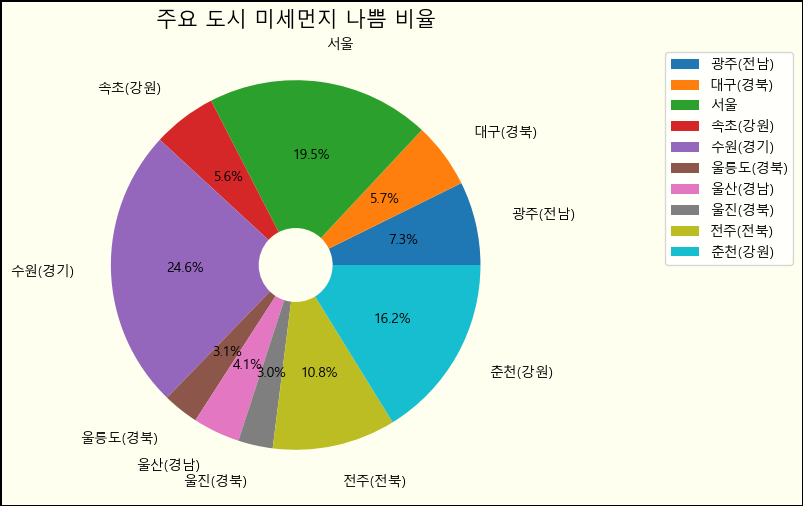

In [24]:
plt.figure(figsize=(10,6), facecolor='ivory', edgecolor='k', linewidth=2)
plt.pie(df_PM_copy_per['per'], labels=df_PM_copy_per.index, labeldistance = 1.2,autopct ='%.1f%%',
       wedgeprops = {'lw':1 ,'width':0.8})
plt.legend(loc=(1.3,0.5))
plt.title('주요 도시 미세먼지 나쁨 비율',size=15)
plt.show()

### 강수량과 미세먼지 비교

In [25]:
df_rela.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 346840 entries, 0 to 346839
Data columns (total 18 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   관측일        346840 non-null  datetime64[ns]
 1   국내 지점번호    346840 non-null  object        
 2   일 평균 풍속    346840 non-null  object        
 3   일 풍정       346840 non-null  object        
 4   최대풍향       346840 non-null  object        
 5   최대풍속       346840 non-null  object        
 6   최대순간풍향     346840 non-null  object        
 7   최대순간풍속     346840 non-null  object        
 8   일 평균기온     346840 non-null  object        
 9   최고기온       346840 non-null  object        
 10  최저기온       346840 non-null  object        
 11  일 평균 상대습도  346840 non-null  object        
 12  최저습도       346840 non-null  object        
 13  일 평균 현지기압  346840 non-null  object        
 14  일 평균 해면기압  346840 non-null  object        
 15  일 평균 전운량   346840 non-null  object        
 16  일사합        346840 no

In [26]:
df_name[df_name['STN_KO']=='전주']

,STN_ID,STN_KO
28,146,전주


In [27]:
df_PM_rain_sok=df_PM[df_PM['STN_KO']=='속초'].copy()
df_rain_sok=df_rela[['관측일','국내 지점번호','일 강수량']]
df_rain_sok = df_rain_sok[df_rain_sok['국내 지점번호']=='90'].copy()
df_rain_sok['관측일'] = df_rain_sok['관측일'].astype('str')

df_PM_rain_sok['TM'] = pd.to_datetime(df_PM_rain_sok['TM']).dt.strftime('%Y-%m-%d')
df_rain_sok['관측일'] = pd.to_datetime(df_rain_sok['관측일']).dt.strftime('%Y-%m-%d')
df_PM_rain_sok=pd.merge(df_PM_rain_sok,df_rain_sok,left_on=['TM','STN_ID'],right_on=['관측일','국내 지점번호'])
df_PM_rain_sok = df_PM_rain_sok.drop(columns=['TM', 'STN_ID','국내 지점번호'])
df_PM_rain_sok.loc[df_PM_rain_sok['일 강수량'] == '-9.0', '일 강수량'] = '0'
df_PM_rain_sok['일 강수량']=df_PM_rain_sok['일 강수량'].astype('float64')

df_PMrain_sok=pd.DataFrame(columns=['PM10농도','평균 강수량'])
for i in range(20,80,20):
    dum = pd.DataFrame({'PM10농도': [str(i)+'~'+str(i+20)],
                        '평균 강수량': [df_PM_rain_sok[(df_PM_rain_sok['PM10'] > i)&(df_PM_rain_sok['PM10']<=i+20)]['일 강수량'].mean()]})
    df_PMrain_sok=pd.concat([df_PMrain_sok,dum])
dum = pd.DataFrame({'PM10농도': ['80~'],
                    '평균 강수량': [df_PM_rain_sok[df_PM_rain_sok['PM10'] > 80]['일 강수량'].mean()]})
df_PMrain_sok=pd.concat([df_PMrain_sok,dum])
df_PMrain_sok.reset_index(drop=True,inplace=True)
df_PMrain_sok

,PM10농도,평균 강수량
0,20~40,2.296127
1,40~60,0.635541
2,60~80,0.461798
3,80~,0.185294


In [28]:
df_PM_rain_dae=df_PM[df_PM['STN_KO']=='대구'].copy()
df_rain_dae=df_rela[['관측일','국내 지점번호','일 강수량']]
df_rain_dae= df_rain_dae[df_rain_dae['국내 지점번호']=='143'].copy()
df_rain_dae['관측일'] = df_rain_dae['관측일'].astype('str')

df_PM_rain_dae['TM'] = pd.to_datetime(df_PM_rain_dae['TM']).dt.strftime('%Y-%m-%d')
df_rain_dae['관측일'] = pd.to_datetime(df_rain_dae['관측일']).dt.strftime('%Y-%m-%d')
df_PM_rain_dae=pd.merge(df_PM_rain_dae,df_rain_dae,left_on=['TM','STN_ID'],right_on=['관측일','국내 지점번호'])
df_PM_rain_dae = df_PM_rain_dae.drop(columns=['TM', 'STN_ID','국내 지점번호'])
df_PM_rain_dae.loc[df_PM_rain_dae['일 강수량'] == '-9.0', '일 강수량'] = '0'
df_PM_rain_dae['일 강수량']=df_PM_rain_dae['일 강수량'].astype('float64')

df_PMrain_dae=pd.DataFrame(columns=['PM10농도','평균 강수량'])
for i in range(20,80,20):
    dum = pd.DataFrame({'PM10농도': [str(i)+'~'+str(i+20)],
                        '평균 강수량': [df_PM_rain_dae[(df_PM_rain_dae['PM10'] > i)&(df_PM_rain_dae['PM10']<=i+20)]['일 강수량'].mean()]})
    df_PMrain_dae=pd.concat([df_PMrain_dae,dum])
dum = pd.DataFrame({'PM10농도': ['80~'],
                    '평균 강수량': [df_PM_rain_dae[df_PM_rain_dae['PM10'] > 80]['일 강수량'].mean()]})
df_PMrain_dae=pd.concat([df_PMrain_dae,dum])
df_PMrain_dae.reset_index(drop=True,inplace=True)
df_PMrain_dae

,PM10농도,평균 강수량
0,20~40,1.662059
1,40~60,0.658468
2,60~80,0.239189
3,80~,0.358571


In [29]:
df_PM_rain_jun=df_PM[df_PM['STN_KO']=='전주'].copy()
df_rain_jun=df_rela[['관측일','국내 지점번호','일 강수량']]
df_rain_jun = df_rain_jun[df_rain_jun['국내 지점번호']=='146'].copy()
df_rain_jun['관측일'] = df_rain_jun['관측일'].astype('str')

df_PM_rain_jun['TM'] = pd.to_datetime(df_PM_rain_jun['TM']).dt.strftime('%Y-%m-%d')
df_rain_jun['관측일'] = pd.to_datetime(df_rain_jun['관측일']).dt.strftime('%Y-%m-%d')
df_PM_rain_jun=pd.merge(df_PM_rain_jun,df_rain_jun,left_on=['TM','STN_ID'],right_on=['관측일','국내 지점번호'])
df_PM_rain_jun = df_PM_rain_jun.drop(columns=['TM', 'STN_ID','국내 지점번호'])
df_PM_rain_jun.loc[df_PM_rain_jun['일 강수량'] == '-9.0', '일 강수량'] = '0'
df_PM_rain_jun['일 강수량']=df_PM_rain_jun['일 강수량'].astype('float64')

df_PMrain_jun=pd.DataFrame(columns=['PM10농도','평균 강수량'])
for i in range(20,80,20):
    dum = pd.DataFrame({'PM10농도': [str(i)+'~'+str(i+20)],
                        '평균 강수량': [df_PM_rain_jun[(df_PM_rain_jun['PM10'] > i)&(df_PM_rain_jun['PM10']<=i+20)]['일 강수량'].mean()]})
    df_PMrain_jun=pd.concat([df_PMrain_jun,dum])
dum = pd.DataFrame({'PM10농도': ['80~'],
                    '평균 강수량': [df_PM_rain_jun[df_PM_rain_jun['PM10'] > 80]['일 강수량'].mean()]})
df_PMrain_jun=pd.concat([df_PMrain_jun,dum])
df_PMrain_jun.reset_index(drop=True,inplace=True)
df_PMrain_jun

,PM10농도,평균 강수량
0,20~40,2.072610
1,40~60,1.055334
2,60~80,1.410360
3,80~,0.522901


In [30]:
df_PM_rain_seo=df_PM[df_PM['STN_KO']=='서울'].copy()
df_rain_seo=df_rela[['관측일','국내 지점번호','일 강수량']]
df_rain_seo = df_rain_seo[df_rain_seo['국내 지점번호']=='108'].copy()
df_rain_seo['관측일'] = df_rain_seo['관측일'].astype('str')

df_PM_rain_seo['TM'] = pd.to_datetime(df_PM_rain_seo['TM']).dt.strftime('%Y-%m-%d')
df_rain_seo['관측일'] = pd.to_datetime(df_rain_seo['관측일']).dt.strftime('%Y-%m-%d')
df_PM_rain_seo=pd.merge(df_PM_rain_seo,df_rain_seo,left_on=['TM','STN_ID'],right_on=['관측일','국내 지점번호'])
df_PM_rain_seo = df_PM_rain_seo.drop(columns=['TM', 'STN_ID','국내 지점번호'])
df_PM_rain_seo['일 강수량']=df_PM_rain_seo['일 강수량'].astype('float64')

df_PMrain_seo=pd.DataFrame(columns=['PM10농도','평균 강수량'])
for i in range(20,80,20):
    dum = pd.DataFrame({'PM10농도': [str(i)+'~'+str(i+20)],
                        '평균 강수량': [df_PM_rain_seo[(df_PM_rain_seo['PM10'] > i)
                                                  &(df_PM_rain_seo['PM10']<=i+20)]['일 강수량'].mean()]})
    df_PMrain_seo=pd.concat([df_PMrain_seo,dum])
dum = pd.DataFrame({'PM10농도': ['80~'],
                    '평균 강수량': [df_PM_rain_seo[df_PM_rain_seo['PM10'] > 80]['일 강수량'].mean()]})
df_PMrain_seo=pd.concat([df_PMrain_seo,dum])
df_PMrain_seo.reset_index(drop=True,inplace=True)
df_PMrain_seo

,PM10농도,평균 강수량
0,20~40,2.609480
1,40~60,1.411157
2,60~80,0.797059
3,80~,0.934454


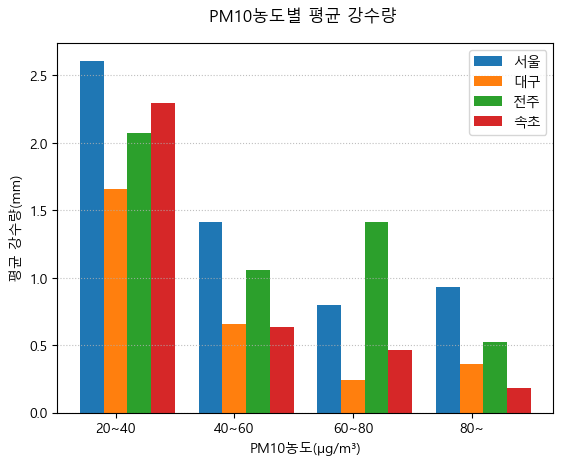

In [31]:
x = np.arange(len(df_PMrain_seo['PM10농도']))
width = 0.2  

plt.bar(x - width, df_PMrain_seo['평균 강수량'], width=width, label='서울')
plt.bar(x, df_PMrain_dae['평균 강수량'], width=width, label='대구')
plt.bar(x + width, df_PMrain_jun['평균 강수량'], width=width, label='전주')
plt.bar(x + 2*width, df_PMrain_sok['평균 강수량'], width=width, label='속초')

plt.xticks(x, df_PMrain_seo['PM10농도'])
plt.legend()
plt.title('PM10농도별 평균 강수량 ',pad='15')
plt.xlabel('PM10농도(µg/m³)')
plt.ylabel('평균 강수량(mm)')
plt.grid(ls=':', alpha=0.8, axis='y')
plt.show()

### 풍속과 미세먼지의 상관관계

In [32]:
df_rela_ws=df_rela[['관측일','국내 지점번호','일 평균 풍속']]
df_rela_ws.head()

,관측일,국내 지점번호,일 평균 풍속
0,2014-01-01,90,5.4
1,2014-01-01,95,3.2
2,2014-01-01,98,2.6
3,2014-01-01,99,2.0
4,2014-01-01,100,10.6


In [33]:
df_PM_ws=df_PM.copy()
df_PM_ws['TM'] = pd.to_datetime(df_PM_ws['TM']).dt.strftime('%Y-%m-%d')
df_rela_ws = df_rela_ws.copy()
df_rela_ws['관측일'] = pd.to_datetime(df_rela_ws['관측일']).dt.strftime('%Y-%m-%d')
df_ws_avg=pd.merge(df_PM_ws,df_rela_ws,left_on=['TM','STN_ID'],right_on=['관측일','국내 지점번호'])
df_ws_avg.drop(columns=['TM','STN_ID'],inplace=True)
df_ws_avg['일 평균 풍속']=df_ws_avg['일 평균 풍속'].astype('float64')

In [34]:
ws_uni=df_ws_avg['STN_KO'].unique()
ws_uni

array(['대관령', '춘천', '백령도', '서울', '울릉도', '수원', '영월', '울진', '추풍령', '안동',
       '군산', '대구', '울산', '광주', '흑산도', '고산', '진주', '강화', '천안', '속초', '전주',
       '진도군', '문경', '북춘천', '영주'], dtype=object)

In [35]:
df_ws_avg_jun=df_ws_avg[df_ws_avg['STN_KO']=='전주']
df_ws_avg_ul=df_ws_avg[df_ws_avg['STN_KO']=='울산']
df_ws_avg_back=df_ws_avg[df_ws_avg['STN_KO']=='백령도']
df_ws_avg_sock=df_ws_avg[df_ws_avg['STN_KO']=='속초']

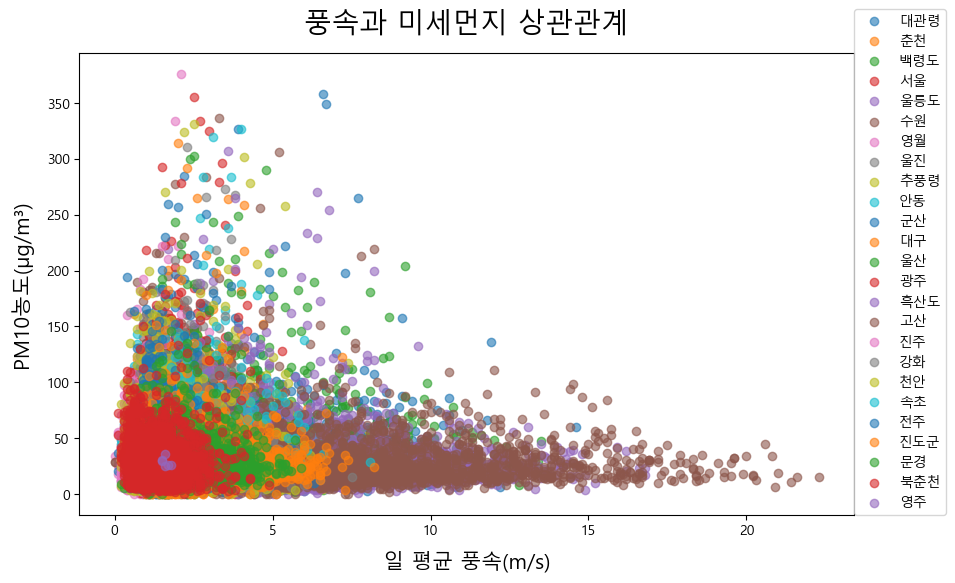

In [36]:
plt.figure(figsize=(10, 6))
for i in ws_uni:
    plt.scatter(df_ws_avg[df_ws_avg['STN_KO']==i]['일 평균 풍속'],
                df_ws_avg[df_ws_avg['STN_KO']==i]['PM10'],
                alpha=0.6,label=i)
plt.ylabel('PM10농도(µg/m³)',labelpad=10,size=15)
plt.xlabel('일 평균 풍속(m/s)',labelpad=10,size=15)
plt.title('풍속과 미세먼지 상관관계',pad=15,size=20)
plt.legend(loc=(1,0))
plt.show()

### 월별 미세먼지 평균 농도

In [37]:
df_PM.head()

,TM,STN_ID,PM10,STN_KO
0,2014-01-01,100,85.902778,대관령
1,2014-01-02,100,34.954861,대관령
2,2014-01-03,100,51.531250,대관령
3,2014-01-04,100,24.895833,대관령
4,2014-01-05,100,28.690972,대관령


In [38]:
df_PM_month=df_PM.copy()
df_PM_month['TM']=pd.to_datetime(df_PM_month['TM'])
df_PM_month['time'] = df_PM_month['TM'].dt.month.astype('str').
                        str.zfill(2)
df_PM_month=df_PM_month.groupby(['time','STN_ID','STN_KO']).
                        mean(numeric_only=True).reset_index()

,time,STN_ID,STN_KO,PM10
0,01,100,대관령,29.162310
1,01,101,춘천,49.968930
2,01,102,백령도,37.216054
3,01,108,서울,51.885634
4,01,115,울릉도,17.228330


In [39]:
monSTN_uni=df_PM_month['STN_KO'].unique()

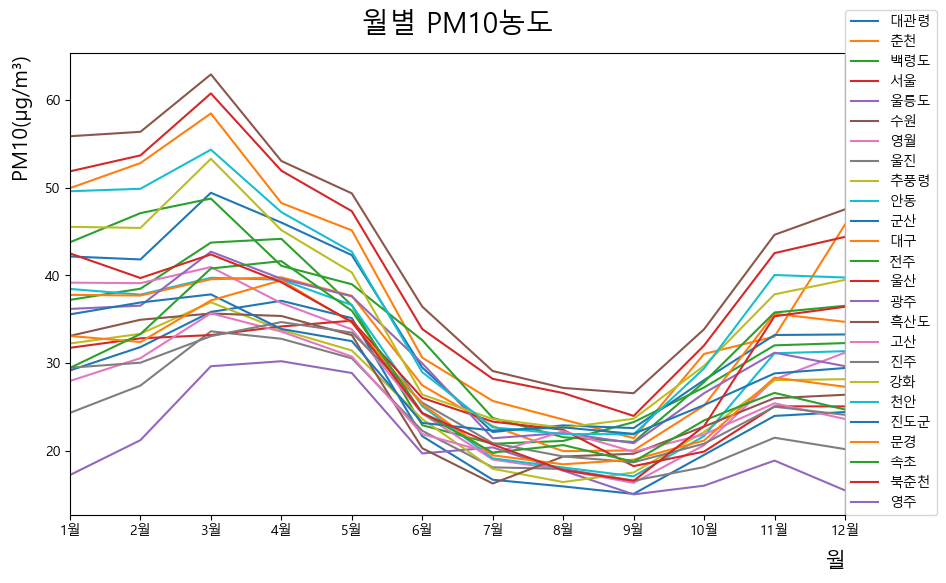

In [40]:
plt.figure(figsize=(10, 6))
for i in monSTN_uni:
    plt.plot(df_PM_month[df_PM_month['STN_KO']==i]['time'],
             df_PM_month[df_PM_month['STN_KO']==i]['PM10'],label=i)

plt.title('월별 PM10농도',pad=15,size=20)
plt.xlabel('월',loc='right',labelpad=10,fontsize=15)
plt.ylabel('PM10(µg/m³)',loc='top',labelpad=10,fontsize=15)

plt.xlim(df_PM_month['time'].min(), df_PM_month['time'].max())

xticks_lable = ['1월','2월','3월','4월','5월','6월','7월'
                ,'8월','9월','10월','11월','12월']
plt.xticks(range(0,12,1),labels=xticks_lable)
plt.legend(loc=(1,0))

plt.show()

### 인구밀도와 미세먼지

In [41]:
df_PM.groupby(['STN_ID','STN_KO']).mean(numeric_only=True).sort_values('PM10').reset_index().head()

,STN_ID,STN_KO,PM10
0,115,울릉도,20.951228
1,130,울진,23.592898
2,100,대관령,25.505679
3,185,고산,26.067407
4,192,진주,26.236326


In [42]:
url='https://sgisapi.kostat.go.kr/OpenAPI3/auth/authentication.json'
consumer_key='3a90c782ab6d488ea112'
consumer_secret='2ac8385e05fe49c69a92'

key_res = requests.get(url,params={'consumer_key':consumer_key,'consumer_secret':consumer_secret})
r_data = key_res.json()
access_token = r_data['result']['accessToken']

In [43]:
# 서울,광역시 데이터
url='https://sgisapi.kostat.go.kr/OpenAPI3/stats/population.json'
ingu_res=requests.get(url,params={'accessToken':access_token,'year':'2022','low_search':'2'})
ingu_data=ingu_res.json()

In [44]:
df_PM['STN_KO'].unique()

array(['대관령', '춘천', '백령도', '서울', '울릉도', '수원', '영월', '울진', '추풍령', '안동',
       '군산', '대구', '울산', '광주', '흑산도', '고산', '진주', '강화', '천안', '속초', '전주',
       '진도군', '문경', '북춘천', '영주'], dtype=object)

In [45]:
df_PM.groupby('STN_KO').mean(numeric_only=True).sort_values('PM10')

,PM10
STN_KO,
울릉도,20.951228
울진,23.592898
대관령,25.505679
고산,26.067407
진주,26.236326
추풍령,26.769239
흑산도,26.929185
울산,27.179613
문경,27.992530


In [46]:
pd.DataFrame(ingu_data['result'])[['adm_cd','adm_nm']]

,adm_cd,adm_nm
0,11,서울특별시
1,21,부산광역시
2,22,대구광역시
3,23,인천광역시
4,24,광주광역시
5,25,대전광역시
6,26,울산광역시
7,29,세종특별자치시
8,31,경기도
9,32,강원특별자치도


In [47]:
#강화 데이터
url='https://sgisapi.kostat.go.kr/OpenAPI3/stats/population.json'
ingu_res_gang=requests.get(url,params={'accessToken':access_token,
                                       'year':'2022','low_search':'0','adm_cd':'23510'})
ingu_data_gang=ingu_res_gang.json()
df_gang=pd.DataFrame(ingu_data_gang['result'])
df_gang=df_gang[['adm_nm','ppltn_dnsty']]
df_gang.columns=['STN_KO','인구밀도']
df_gang['인구밀도']=df_gang['인구밀도'].astype('float64')

df_gang['STN_KO'] = '강화'
df_gang = df_gang.groupby('STN_KO')['인구밀도'].mean().reset_index()
df_gang

,STN_KO,인구밀도
0,강화,156.9


In [48]:
#군산 데이터
url='https://sgisapi.kostat.go.kr/OpenAPI3/stats/population.json'
ingu_res_goon=requests.get(url,params={'accessToken':access_token,'year':'2022','low_search':'0','adm_cd':'35020'})
ingu_data_goon=ingu_res_goon.json()
df_goon=pd.DataFrame(ingu_data_goon['result'])
df_goon=df_goon[['adm_nm','ppltn_dnsty']]
df_goon.columns=['STN_KO','인구밀도']
df_goon['인구밀도']=df_goon['인구밀도'].astype('float64')

df_goon['STN_KO'] = '군산'
df_goon = df_goon.groupby('STN_KO')['인구밀도'].mean().reset_index()
df_goon

,STN_KO,인구밀도
0,군산,611.6


In [49]:
# 수원 데이터
url='https://sgisapi.kostat.go.kr/OpenAPI3/stats/population.json'
ingu_res_su=requests.get(url,params={'accessToken':access_token,'year':'2022','low_search':'1','adm_cd':'31'})
ingu_data_su=ingu_res_su.json()
df_su=[item for item in ingu_data_su['result'] if '수원시' in item['adm_nm']]
df_su=pd.DataFrame(df_su)
df_su=df_su[['adm_nm','ppltn_dnsty']]
df_su.columns=['STN_KO','인구밀도']
df_su['인구밀도']=df_su['인구밀도'].astype('float64')

df_su['STN_KO'] = '수원'
df_su = df_su.groupby('STN_KO')['인구밀도'].mean().reset_index()
df_su

,STN_KO,인구밀도
0,수원,10575.85


In [50]:
#속초 데이터
url='https://sgisapi.kostat.go.kr/OpenAPI3/stats/population.json'
ingu_res_sok=requests.get(url,params={'accessToken':access_token,'year':'2022','low_search':'0','adm_cd':'32060'})
ingu_data_sok=ingu_res_sok.json()
df_sok=pd.DataFrame(ingu_data_sok['result'])
df_sok=df_sok[['adm_nm','ppltn_dnsty']]
df_sok.columns=['STN_KO','인구밀도']
df_sok['인구밀도']=df_sok['인구밀도'].astype('float64')

df_sok['STN_KO'] = '속초'
df_sok = df_sok.groupby('STN_KO')['인구밀도'].mean().reset_index()
df_sok

,STN_KO,인구밀도
0,속초,741.6


In [51]:
#울릉도 데이터
ingu_res_ulleung=requests.get(url,params={'accessToken':access_token,'year':'2022','low_search':'0','adm_cd':'37630'})
ingu_data_ulleung=ingu_res_ulleung.json()
df_ulleung=pd.DataFrame(ingu_data_ulleung['result'])
df_ulleung=df_ulleung[['adm_nm','ppltn_dnsty']]
df_ulleung.columns=['STN_KO','인구밀도']
df_ulleung['인구밀도']=df_ulleung['인구밀도'].astype('float64')

df_ulleung['STN_KO'] = '울릉도'
df_ulleung = df_ulleung.groupby('STN_KO')['인구밀도'].mean().reset_index()
df_ulleung

,STN_KO,인구밀도
0,울릉도,108.7


In [52]:
df_ingu=pd.DataFrame(ingu_data['result'])
df_ingu_den=df_ingu[['adm_nm','ppltn_dnsty']]
df_ingu_den.columns=['STN_KO','인구밀도']
inhu_lst=['서울특별시','대구광역시','광주광역시','울산광역시']
df_ingu_den=df_ingu_den[df_ingu_den['STN_KO'].isin(inhu_lst)]
df_ingu_den['STN_KO'] = df_ingu_den['STN_KO'].replace({'서울특별시':'서울', '대구광역시':'대구', '광주광역시':'광주', '울산광역시':'울산'})
df_ingu_den=pd.concat([df_ingu_den,df_sok,df_su,df_ulleung,df_gang,df_goon])
df_ingu_den.head()

,STN_KO,인구밀도
0,서울,14845.9
2,대구,1560.5
4,광주,2857.7
6,울산,1011.2
0,속초,741.6


In [53]:
df_year=df_PM.groupby(['STN_ID','STN_KO']).mean(numeric_only=True).reset_index()
df_ingu_den=pd.merge(df_ingu_den,df_year)
df_ingu_den['인구밀도']=df_ingu_den['인구밀도'].astype('float64')

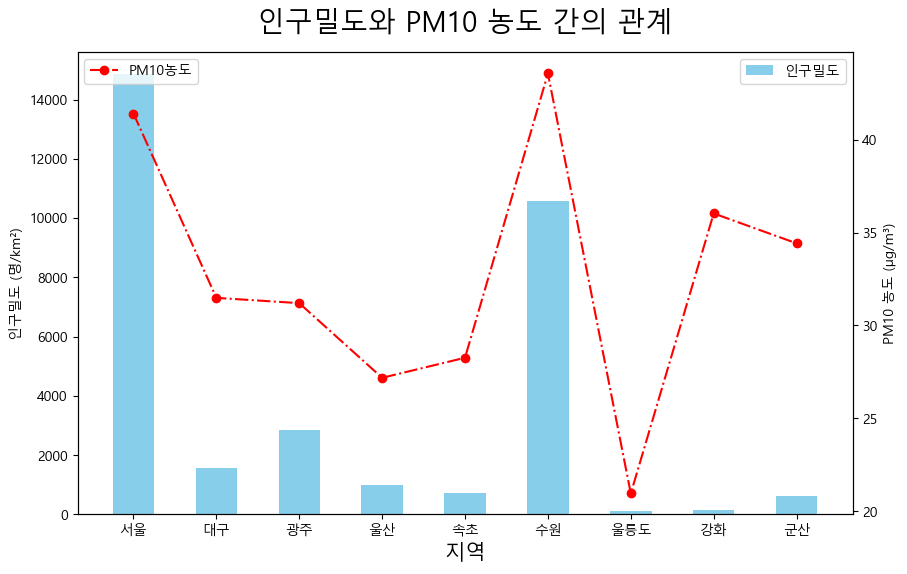

In [54]:
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.bar(df_ingu_den['STN_KO'],df_ingu_den['인구밀도'], width=0.5,color='skyblue',label='인구밀도')

ax2 = ax1.twinx()
ax2.plot(df_ingu_den['STN_KO'],df_ingu_den['PM10'], marker='o', ls='-.', label='PM10농도',color='r')

plt.title('인구밀도와 PM10 농도 간의 관계',pad=15,size=20)

ax1.set_xlabel('지역',size=15)
ax1.set_ylabel('인구밀도 (명/km²)')
ax2.set_ylabel('PM10 농도 (µg/m³)')
ax1.legend(loc='upper right')
ax2.legend(loc='upper left')
plt.show()

### PM10 측정 위치 지도

In [55]:
df_len=pd.merge(df_inf[['STN_ID','STN_KO','LON','LAT']],df_PM10_d)
df_len=df_len.groupby(['STN_KO','LON','LAT']).mean('PM10').reset_index()
df_len.head()

,STN_KO,LON,LAT,PM10
0,강화,126.44634000,37.70739000,40.507826
1,고산,126.16283000,33.29382000,26.769260
2,광주,126.89156000,35.17294000,34.582355
3,군산,126.76135000,36.00530000,36.657631
4,대관령,128.71834000,37.67713000,28.046976


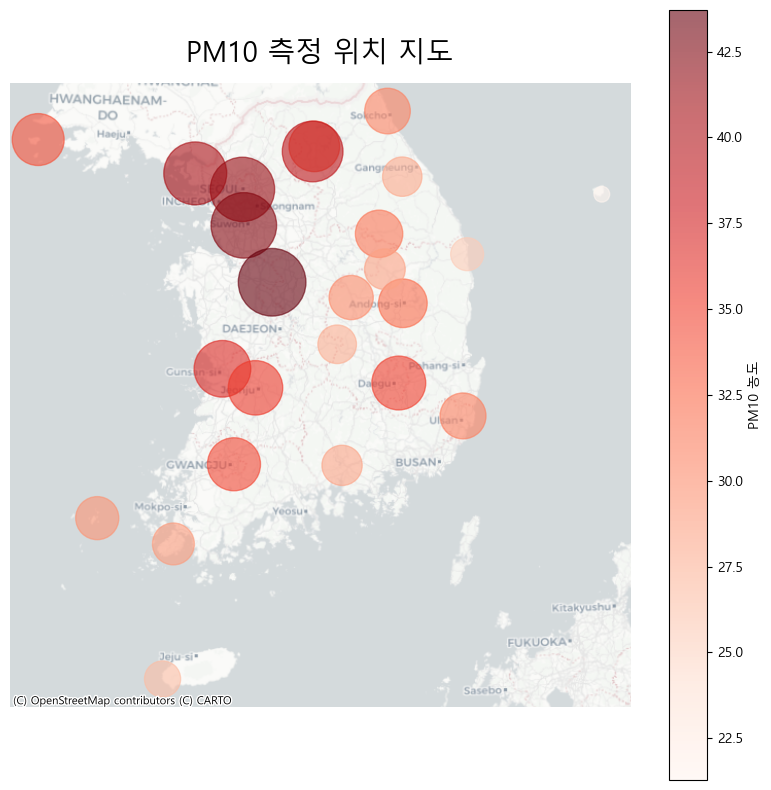

In [56]:
gdf = gpd.GeoDataFrame(df_len, geometry=gpd.points_from_xy(df_len.LON, df_len.LAT))

gdf.set_crs(epsg=4326, inplace=True)
gdf = gdf.to_crs(epsg=5179)

fig, ax = plt.subplots(figsize=(10, 10))

norm = plt.Normalize(vmin=gdf['PM10'].min(), vmax=gdf['PM10'].max())
cmap = plt.cm.Reds 
sc = ax.scatter(gdf.geometry.x, gdf.geometry.y, s=(gdf['PM10']-20)*100,
                c=gdf['PM10'], cmap=cmap, norm=norm, alpha=0.6)
ctx.add_basemap(ax, crs=gdf.crs.to_string(), source=ctx.providers.CartoDB.Positron)

cbar = plt.colorbar(sc, ax=ax, orientation='vertical')
cbar.set_label('PM10 농도')

plt.title('PM10 측정 위치 지도',size=20,pad=15)
ax.set_axis_off()
plt.show()

### 연도별 미세먼지 평균

In [57]:
df_PMyear=df_PM.copy()
df_PMyear['TM']=pd.to_datetime(df_PMyear['TM'])
df_PMyear=df_PMyear.groupby([df_PMyear['TM'].dt.year,'STN_KO','STN_ID']).mean(numeric_only=True).reset_index()
df_PMyear['TM']=df_PMyear['TM'].astype('str')
df_PMyear

,TM,STN_KO,STN_ID,PM10
0,2014,강화,201,45.190513
1,2014,고산,185,29.885855
2,2014,광주,156,39.272000
3,2014,군산,140,41.247580
4,2014,대관령,100,32.397708
...,...,...,...,...
225,2023,진도군,268,33.814070
226,2023,진주,192,25.083076
227,2023,천안,232,32.114668
228,2023,추풍령,135,26.632832


In [58]:
df_PMyear_nm=df_PMyear['STN_KO'].unique()
df_PMyear_nm

array(['강화', '고산', '광주', '군산', '대관령', '대구', '백령도', '서울', '속초', '수원', '안동',
       '영월', '울릉도', '울산', '울진', '전주', '진주', '천안', '추풍령', '춘천', '흑산도',
       '문경', '진도군', '북춘천', '영주'], dtype=object)

In [59]:
df_PMyear['TM'].unique()

array(['2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021',
       '2022', '2023'], dtype=object)

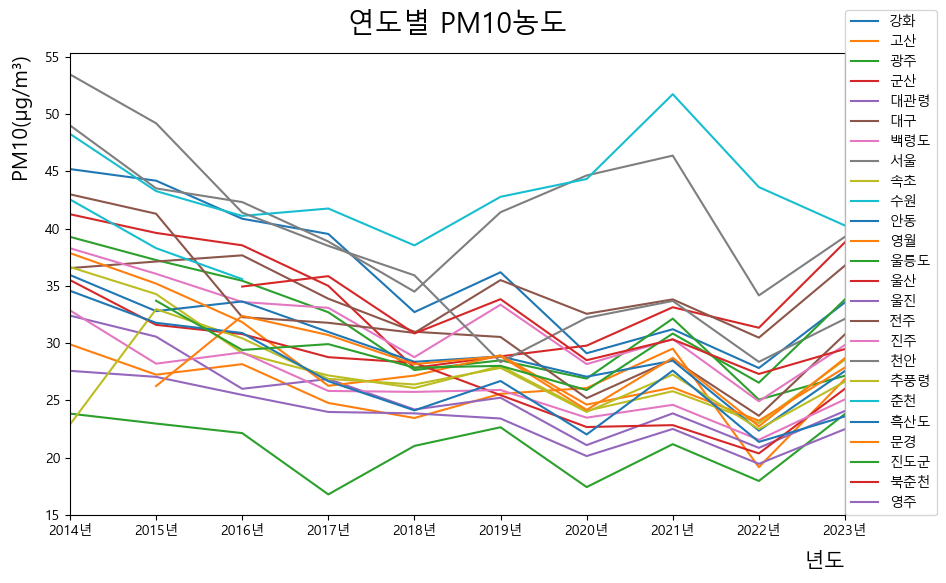

In [60]:
plt.figure(figsize=(10, 6))
for i in df_PMyear_nm:
    plt.plot(df_PMyear[df_PMyear['STN_KO']==i]['TM'],df_PMyear[df_PMyear['STN_KO']==i]['PM10'],label=i)

plt.title('연도별 PM10농도',pad=15,size=20)
plt.xlabel('년도',loc='right',labelpad=10,fontsize=15)
plt.ylabel('PM10(µg/m³)',loc='top',labelpad=10,fontsize=15)

plt.xlim(df_PMyear['TM'].min(), df_PMyear['TM'].max())

xticks_lable = ['2014년','2015년','2016년','2017년','2018년','2019년','2020년','2021년','2022년','2023년']
plt.xticks(range(0,10,1),labels=xticks_lable)
plt.legend(loc=(1,0))

plt.show()